# LeetCode #130: Surrounded Regions

https://leetcode.com/problems/surrounded-regions/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Check each O's border connectivity | O((n·m)²) | O(n·m) | TLE on large boards |
| **DFS from border O's** | **O(n·m)** | **O(n·m)** | **Optimal — one pass from border** |

## Understanding the Method

Any 'O' connected to the border cannot be captured. Strategy:
1. DFS/BFS from all border 'O's, marking them as 'S' (safe)
2. Scan the board: 'O' becomes 'X' (surrounded), 'S' becomes 'O' (restore)

## Constraints

- `m == board.length`, `n == board[i].length`
- `1 <= m, n <= 200`
- `board[i][j]` is `'X'` or `'O'`

## Solutions

### C#

In [ ]:
public class Solution {
    char[][] _board;
    public void Solve(char[][] board) {
        _board = board;
        int m = board.Length, n = board[0].Length;
        for (int i = 0; i < m; i++) { Dfs(i, 0); Dfs(i, n-1); }
        for (int j = 0; j < n; j++) { Dfs(0, j); Dfs(m-1, j); }
        for (int i = 0; i < m; i++)
            for (int j = 0; j < n; j++)
                board[i][j] = board[i][j] == 'S' ? 'O' : board[i][j] == 'O' ? 'X' : 'X';
    }
    void Dfs(int r, int c) {
        if (r < 0 || r >= _board.Length || c < 0 || c >= _board[0].Length || _board[r][c] != 'O') return;
        _board[r][c] = 'S';
        Dfs(r+1,c); Dfs(r-1,c); Dfs(r,c+1); Dfs(r,c-1);
    }
}

### Python

In [ ]:
class Solution:
    def solve(self, board: list[list[str]]) -> None:
        m, n = len(board), len(board[0])
        def dfs(r, c):
            if r < 0 or r >= m or c < 0 or c >= n or board[r][c] != 'O':
                return
            board[r][c] = 'S'
            dfs(r+1,c); dfs(r-1,c); dfs(r,c+1); dfs(r,c-1)
        for i in range(m):
            dfs(i, 0); dfs(i, n-1)
        for j in range(n):
            dfs(0, j); dfs(m-1, j)
        for r in range(m):
            for c in range(n):
                if board[r][c] == 'O': board[r][c] = 'X'
                elif board[r][c] == 'S': board[r][c] = 'O'

### Go

In [ ]:
func solve(board [][]byte) {
    m, n := len(board), len(board[0])
    var dfs func(r, c int)
    dfs = func(r, c int) {
        if r < 0 || r >= m || c < 0 || c >= n || board[r][c] != 'O' { return }
        board[r][c] = 'S'
        dfs(r+1,c); dfs(r-1,c); dfs(r,c+1); dfs(r,c-1)
    }
    for i := 0; i < m; i++ { dfs(i, 0); dfs(i, n-1) }
    for j := 0; j < n; j++ { dfs(0, j); dfs(m-1, j) }
    for r := 0; r < m; r++ {
        for c := 0; c < n; c++ {
            if board[r][c] == 'O' { board[r][c] = 'X' } else if board[r][c] == 'S' { board[r][c] = 'O' }
        }
    }
}

### Rust

In [ ]:
impl Solution {
    pub fn solve(board: &mut Vec<Vec<char>>) {
        let m = board.len();
        let n = board[0].len();
        fn dfs(board: &mut Vec<Vec<char>>, r: i32, c: i32, m: i32, n: i32) {
            if r < 0 || r >= m || c < 0 || c >= n || board[r as usize][c as usize] != 'O' { return; }
            board[r as usize][c as usize] = 'S';
            dfs(board,r+1,c,m,n); dfs(board,r-1,c,m,n);
            dfs(board,r,c+1,m,n); dfs(board,r,c-1,m,n);
        }
        for i in 0..m as i32 { dfs(board, i, 0, m as i32, n as i32); dfs(board, i, n as i32-1, m as i32, n as i32); }
        for j in 0..n as i32 { dfs(board, 0, j, m as i32, n as i32); dfs(board, m as i32-1, j, m as i32, n as i32); }
        for r in 0..m { for c in 0..n {
            if board[r][c] == 'O' { board[r][c] = 'X'; }
            else if board[r][c] == 'S' { board[r][c] = 'O'; }
        }}
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `board = [["X","X","X","X"],["X","O","O","X"],["X","X","O","X"],["X","O","X","X"]]`  
Border DFS marks $(3,1)$ as Safe. Inner O's at $(1,1)$, $(1,2)$, $(2,2)$ have no border connection and are captured to X. Border O at $(3,1)$ reverts from S back to O.  
WHY tricky: Border O at bottom-left must be preserved while surrounded inner O's are captured — tests correct border scanning.  
**Output:** 3 O's captured, 1 border O preserved

### 2. Slightly Complex
**Input:** `board = [["O","X","O","O","X"],["X","O","X","X","O"],["X","O","X","O","X"],["O","X","O","X","O"]]`  
Multiple border O's create several disconnected safe components. Interior O's at $(1,1)$ and $(2,1)$ connect vertically but reach no border, so they are captured. Corners and edge O's are all safe.  
WHY tricky: Multiple disconnected border O groups and interior O's connected vertically — tests DFS traversal in all 4 directions correctly.  
**Output:** Interior O's captured; all border-connected O's preserved

### 3. Edge Case: Time Factor
**Input:** $200 \times 200$ board, all O's connected to the border  
Worst case for DFS: a single connected component of $O(n \cdot m) = 40{,}000$ cells, all reachable from the border. DFS visits each cell exactly once.  
WHY tricky: $200 \times 200 = 40{,}000$ cells at max constraint. DFS must handle it in one pass without TLE. Naive approach would be $O((n \cdot m)^2)$.  
**Output:** Processed in $O(n \cdot m)$ time

### 4. Edge Case: Space Factor
**Input:** $200 \times 200$ board entirely filled with O's  
Every cell is O and connected to the border. DFS recursion can traverse all 40,000 cells — recursion stack reaches $O(n \cdot m) = 40{,}000$ frames, risking stack overflow (~2 MB).  
WHY tricky: Recursive DFS on $40{,}000$ connected O's may overflow the default $\sim1$ MB call stack. BFS with an explicit queue limits space to $O(\min(n,m))$.  
**Output:** No captures — all O's border-connected. Watch for stack overflow.

### 5. Almost-Impossible but Plausible
**Input:** `board = [["O"]]` ($1 \times 1$ board)  
Single cell is simultaneously on all four borders. A border O cannot be captured. The algorithm marks it Safe, then restores it.  
WHY tricky: Minimum board size $m = n = 1$. Every cell is a border cell. Tests boundary conditions for the border-scanning loop and ensures no out-of-bounds access.  
**Output:** `[["O"]]` — unchanged

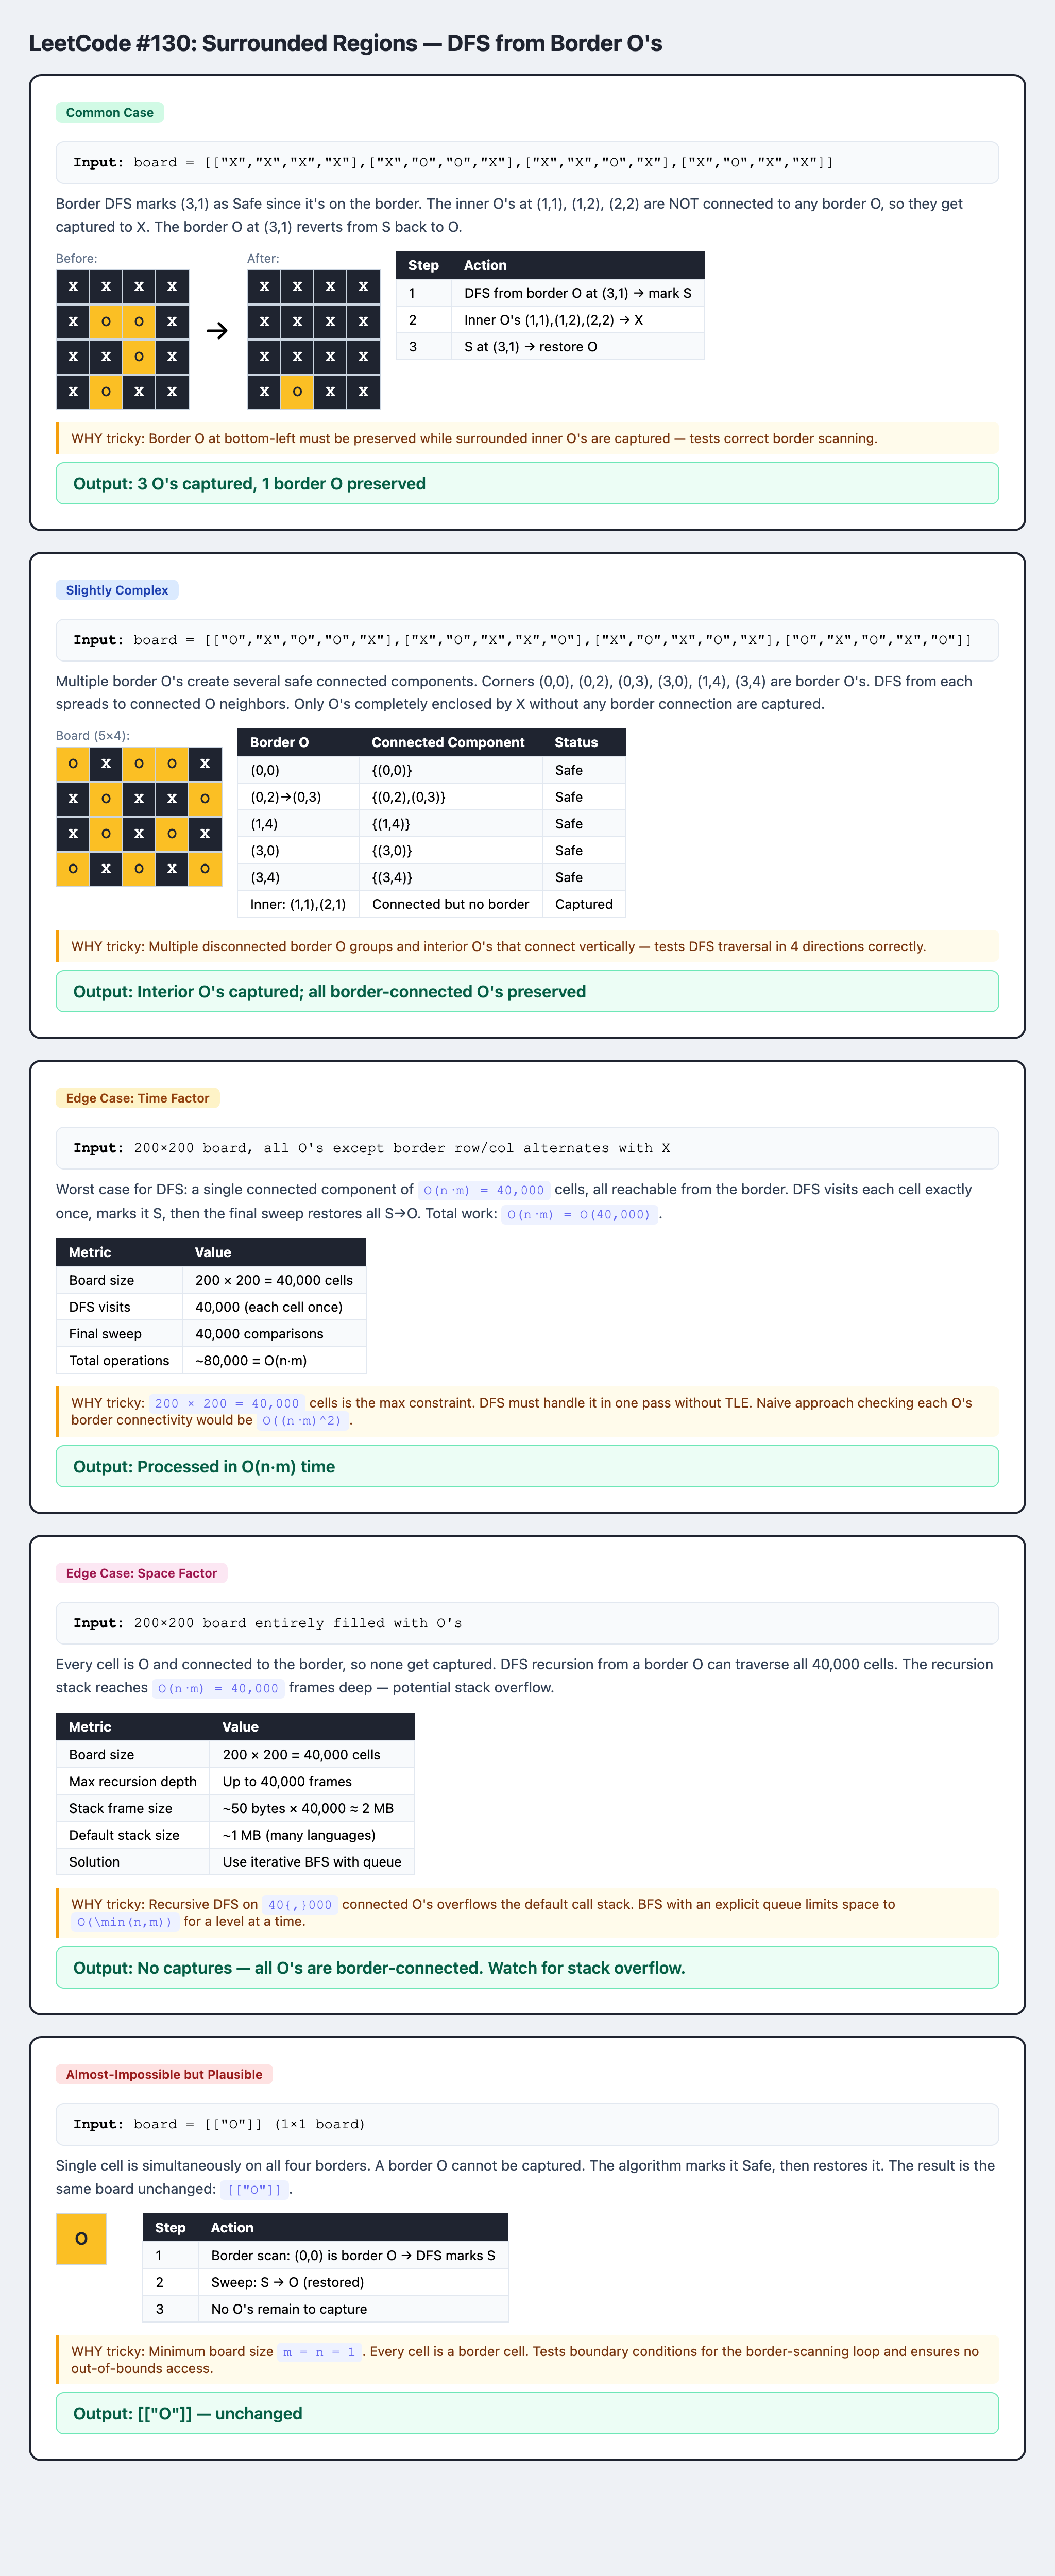